## Phase 1: Run Linear Probes on Single Datasets: LLaMA-2-7B on SQuAD (5k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.
* [Done] Take some time to alter the llama codes for keeping residuals and attention outputs.
* We use this larger dataset as an example for **training probes on concatenated inputs.**

<!-- Preliminarily, we find that `SLT` token at layer `21` is the most effective at predicting binarized SE, while layer `32` is the most effective for predicting Accuracy from probes trained on b-SE.
 -->
<!-- `TBG` token is less effective than `SLT` token. -->

Using concatenated inputs have marginal benefits (e.g. from `0.7420` to `0.7572` best AUROC on predicting Accuracy with probes trained on b-SE), by concatenating input embeddings encompassing the top 10 best layers.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240502_040140-j48o601d/files')  # path for llama2-7b on squad (5k)

Matplotlib created a temporary cache directory at /tmp/matplotlib-oiwimozz because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


## Utility Functions

In [2]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [3]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([5000]) tensor([2.1640, 0.6390, 1.6094,  ..., 1.2275, 1.6957, 1.4708])


In [4]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. 

In this section, we only prepare datasets for later transfer learning tasks.

In [5]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
entropy = entropy.to(torch.float32)
ca_entropy = entropy.clone()
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.7094) tensor(0.6032)
torch.Size([5000, 33, 4096]) torch.Size([5000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [6]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 5000, 4096])


In [7]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [8]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [156]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

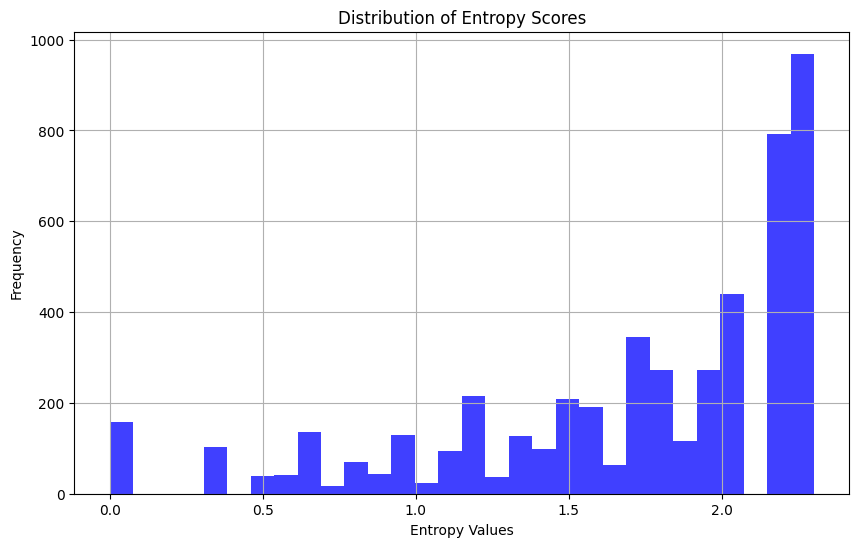

In [10]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

1.418764571989277

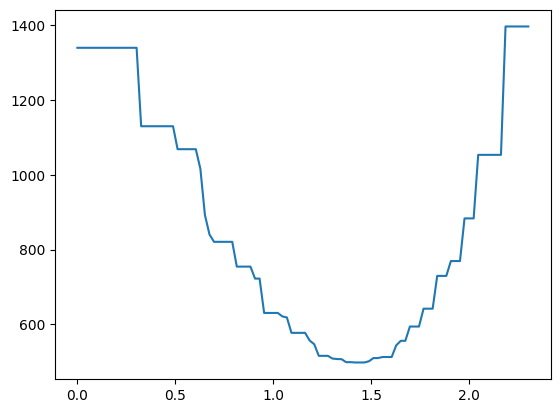

In [11]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [ ]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
# bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

In [143]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [15]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.6578, AUROC: 0.6692
Training Loss: 0.5656, Validation Loss: 0.6266
Test Loss: 0.6445, Test Accuracy: 0.6080, AUROC: 0.6231
Training on Dataset 2/33
Validation Accuracy: 0.6467, AUROC: 0.6899
Training Loss: 0.5255, Validation Loss: 0.6149
Test Loss: 0.6439, Test Accuracy: 0.6100, AUROC: 0.6372
Training on Dataset 3/33
Validation Accuracy: 0.6633, AUROC: 0.7117
Training Loss: 0.4595, Validation Loss: 0.6121
Test Loss: 0.6346, Test Accuracy: 0.6540, AUROC: 0.6758
Training on Dataset 4/33
Validation Accuracy: 0.6600, AUROC: 0.7048
Training Loss: 0.3971, Validation Loss: 0.6372
Test Loss: 0.6434, Test Accuracy: 0.6500, AUROC: 0.6886
Training on Dataset 5/33
Validation Accuracy: 0.6489, AUROC: 0.6868
Training Loss: 0.3517, Validation Loss: 0.6873
Test Loss: 0.6547, Test Accuracy: 0.6900, AUROC: 0.7124
Training on Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6589, AUROC: 0.6972
Training Loss: 0.3041, Validation Loss: 0.7174
Test Loss: 0.7021, Test Accuracy: 0.6940, AUROC: 0.7147
Training on Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6667, AUROC: 0.7087
Training Loss: 0.2528, Validation Loss: 0.7504
Test Loss: 0.7162, Test Accuracy: 0.6860, AUROC: 0.7314
Training on Dataset 8/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7333, AUROC: 0.7848
Training Loss: 0.0024, Validation Loss: 1.7744
Test Loss: 2.1504, Test Accuracy: 0.6980, AUROC: 0.7631
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7156, AUROC: 0.7790
Training Loss: 0.0021, Validation Loss: 1.9608
Test Loss: 2.1552, Test Accuracy: 0.7120, AUROC: 0.7745
Training on Dataset 33/33
Validation Accuracy: 0.6989, AUROC: 0.7523
Training Loss: 0.0040, Validation Loss: 2.2960
Test Loss: 2.4615, Test Accuracy: 0.6940, AUROC: 0.7449


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


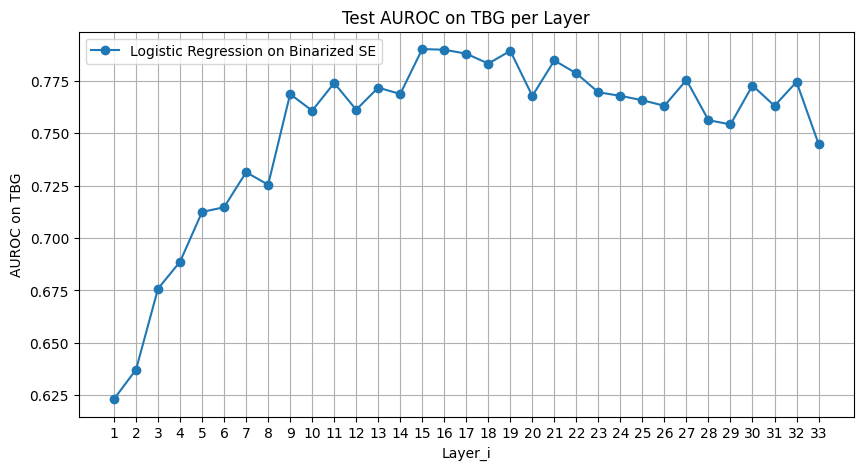

In [45]:
plot_1d_metrics([tblr_test_aucs], ['Logistic Regression on Binarized SE'], 'AUROC on TBG')

In [16]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.7901 at layer 15


#### Concatenated Inputs for Training Probes

We select the top-k best layers and concatenate them for training.

In [103]:
def concat_Xs_and_ys(layer_range, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests):
    X_train_cc = np.concatenate(np.array(X_trains)[layer_range], axis=1)
    X_val_cc = np.concatenate(np.array(X_vals)[layer_range], axis=1)
    X_test_cc = np.concatenate(np.array(X_tests)[layer_range], axis=1)
    y_train_cc = y_trains[layer_range[0]]
    y_val_cc = y_vals[layer_range[0]]
    y_test_cc = y_tests[layer_range[0]]
    return X_train_cc, X_val_cc, X_test_cc, y_train_cc, y_val_cc, y_test_cc

In [144]:
# Save models for testing on Accuracy
from sklearn.base import clone
tblr_best_auc_indices = np.argsort(tblr_test_aucs)[::-1]

topktblr_test_accs = {}
topktblr_test_aucs = {}
topktblr_models = {}

for top_k in range(1, 10):
    indices = tblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktblr_test_accs[tuple(indices)] = test_acc
    topktblr_test_aucs[tuple(indices)] = test_auc
    topktblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [15]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7333, AUROC: 0.7876
Training Loss: 0.0486, Validation Loss: 1.0008
Test Loss: 1.0073, Test Accuracy: 0.7180, AUROC: 0.7901
Training on top-2 Datasets indexed [15, 16]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7256, AUROC: 0.7915
Training Loss: 0.0222, Validation Loss: 1.0834
Test Loss: 1.0759, Test Accuracy: 0.7180, AUROC: 0.7967
Training on top-3 Datasets indexed [15, 16, 19]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7478, AUROC: 0.7920
Training Loss: 0.0085, Validation Loss: 1.1753
Test Loss: 1.0968, Test Accuracy: 0.7260, AUROC: 0.7997
Training on top-4 Datasets indexed [15, 16, 19, 17]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7433, AUROC: 0.7904
Training Loss: 0.0071, Validation Loss: 1.2315
Test Loss: 1.1460, Test Accuracy: 0.7220, AUROC: 0.8000
Training on top-5 Datasets indexed [15, 16, 19, 17, 21]
Validation Accuracy: 0.7267, AUROC: 0.7899
Training Loss: 0.0044, Validation Loss: 1.3173
Test Loss: 1.2275, Test Accuracy: 0.7200, AUROC: 0.8060
Training on top-6 Datasets indexed [15, 16, 19, 17, 21, 18]
Validation Accuracy: 0.7267, AUROC: 0.7897
Training Loss: 0.0039, Validation Loss: 1.3652
Test Loss: 1.2628, Test Accuracy: 0.7220, AUROC: 0.8040
Training on top-7 Datasets indexed [15, 16, 19, 17, 21, 18, 22]
Validation Accuracy: 0.7178, AUROC: 0.7859
Training Loss: 0.0028, Validation Loss: 1.4953
Test Loss: 1.3875, Test Accuracy: 0.7260, AUROC: 0.8023
Training on top-8 Datasets indexed [15, 16, 19, 17, 21, 18, 22, 27]
Validation Accuracy: 0.7356, AUROC: 0.7911
Training Loss: 0.0016, Validation Loss: 1.6173
Test Loss: 1.5406, Test Accuracy: 0.7280, AUROC: 0.8075
Training on top-9 Data

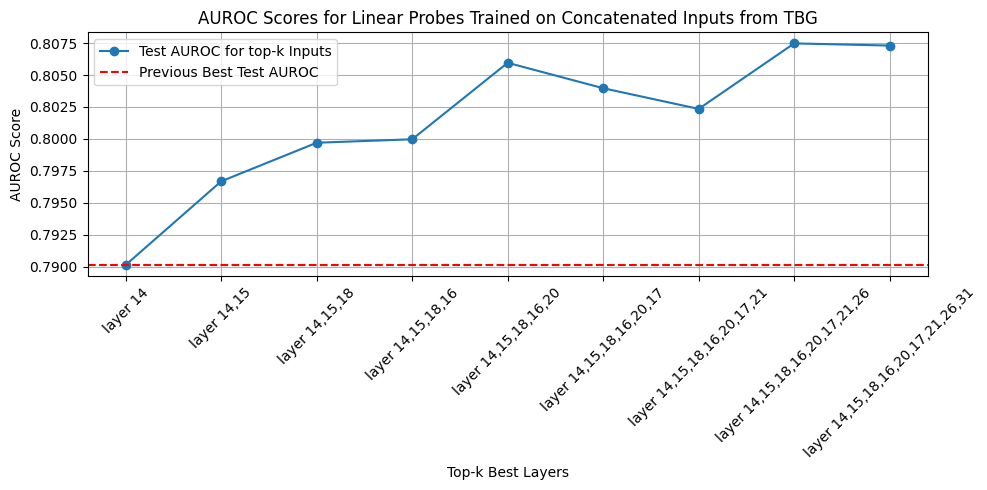

In [157]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(tblr_test_aucs), topktblr_test_aucs, 'TBG')

### Explore Second Last generated Token (SLT)


In [17]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([5000, 33, 4096])


In [18]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 5000, 4096])

In [19]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 5000, 4096]) torch.float32


In [139]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [21]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.6222, AUROC: 0.5000
Training Loss: 0.6707, Validation Loss: 0.6636
Test Loss: 0.6671, Test Accuracy: 0.6140, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.6222, AUROC: 0.5910
Training Loss: 0.6628, Validation Loss: 0.6578
Test Loss: 0.6590, Test Accuracy: 0.6140, AUROC: 0.6153
Training on Dataset 3/33
Validation Accuracy: 0.6222, AUROC: 0.6081
Training Loss: 0.6583, Validation Loss: 0.6541
Test Loss: 0.6526, Test Accuracy: 0.6140, AUROC: 0.6303
Training on Dataset 4/33
Validation Accuracy: 0.6411, AUROC: 0.6458
Training Loss: 0.6386, Validation Loss: 0.6392
Test Loss: 0.6312, Test Accuracy: 0.6440, AUROC: 0.6814
Training on Dataset 5/33
Validation Accuracy: 0.6433, AUROC: 0.6623
Training Loss: 0.6191, Validation Loss: 0.6276
Test Loss: 0.6148, Test Accuracy: 0.6600, AUROC: 0.7097
Training on Dataset 6/33
Validation Accuracy: 0.6656, AUROC: 0.6972
Training Loss: 0.5746, Validation Loss: 0.6051
Test Loss: 0.5870, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6811, AUROC: 0.7126
Training Loss: 0.5366, Validation Loss: 0.5976
Test Loss: 0.5705, Test Accuracy: 0.7080, AUROC: 0.7540
Training on Dataset 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6978, AUROC: 0.7385
Training Loss: 0.4770, Validation Loss: 0.5826
Test Loss: 0.5668, Test Accuracy: 0.7020, AUROC: 0.7593
Training on Dataset 9/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7633, AUROC: 0.8108
Training Loss: 0.0021, Validation Loss: 1.8319
Test Loss: 1.7730, Test Accuracy: 0.7720, AUROC: 0.8272
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7578, AUROC: 0.8196
Training Loss: 0.0020, Validation Loss: 1.7803
Test Loss: 1.8567, Test Accuracy: 0.7540, AUROC: 0.8189
Training on Dataset 33/33
Validation Accuracy: 0.7411, AUROC: 0.7992
Training Loss: 0.0046, Validation Loss: 1.9561
Test Loss: 1.9707, Test Accuracy: 0.7540, AUROC: 0.8063


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


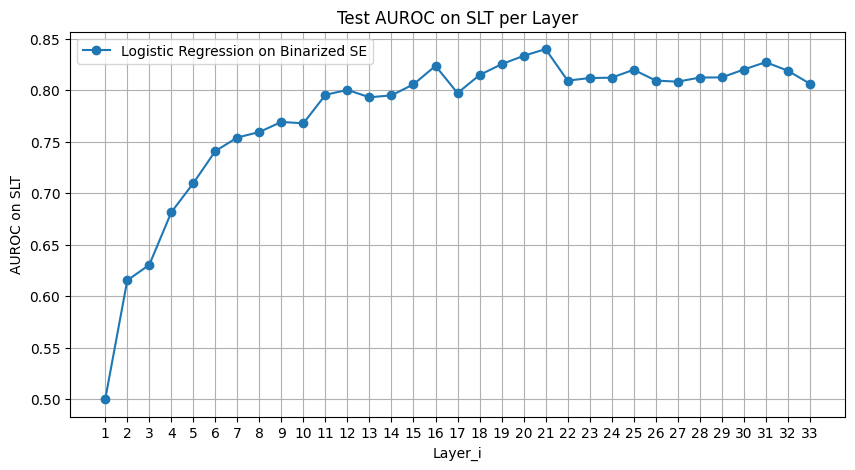

In [72]:
plot_1d_metrics([sblr_test_aucs], ['Logistic Regression on Binarized SE'], 'AUROC on SLT')

In [22]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.8399 at layer 21


#### Concatenated Inputs for Training Probes

In [73]:
# Simply iterate through the layer upper-bound 
# min_layer = np.argmax(sblr_test_aucs)
# all_max_layer = len(sblr_test_aucs) + 1

# Make it manual
min_layer = 16
all_max_layer = 22

ccsblr_test_accs = {(min_layer, max_layer): 0.0 for max_layer in range(min_layer+1, all_max_layer)}
ccsblr_test_aucs = {(min_layer, max_layer): 0.0 for max_layer in range(min_layer+1, all_max_layer)}

for max_layer in range(min_layer+1, all_max_layer):
    print(f"Training on Concatenated Inputs from layer {min_layer} to layer {max_layer}")
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(min_layer, max_layer, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    ccsblr_test_accs[(min_layer, max_layer)] = test_acc
    ccsblr_test_aucs[(min_layer, max_layer)] = test_auc

print(ccsblr_test_aucs)

Training on Concatenated Inputs from layer 16 to layer 17


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7267, AUROC: 0.7835
Training Loss: 0.0534, Validation Loss: 0.9875
Test Loss: 0.8955, Test Accuracy: 0.7420, AUROC: 0.7972
Training on Concatenated Inputs from layer 16 to layer 18


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7389, AUROC: 0.7878
Training Loss: 0.0218, Validation Loss: 1.1658
Test Loss: 0.9810, Test Accuracy: 0.7500, AUROC: 0.8145
Training on Concatenated Inputs from layer 16 to layer 19


...

Validation Accuracy: 0.7444, AUROC: 0.7917
Training Loss: 0.0114, Validation Loss: 1.2917
Test Loss: 1.0496, Test Accuracy: 0.7720, AUROC: 0.8307
Training on Concatenated Inputs from layer 16 to layer 20


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7422, AUROC: 0.7996
Training Loss: 0.0075, Validation Loss: 1.3451
Test Loss: 1.1496, Test Accuracy: 0.7760, AUROC: 0.8354
Training on Concatenated Inputs from layer 16 to layer 21


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7456, AUROC: 0.8118
Training Loss: 0.0046, Validation Loss: 1.3359
Test Loss: 1.1689, Test Accuracy: 0.7680, AUROC: 0.8410
{(16, 17): 0.7971511029349716, (16, 18): 0.814517898432094, (16, 19): 0.8307201566218292, (16, 20): 0.8354120605559399, (16, 21): 0.8409984641609424}


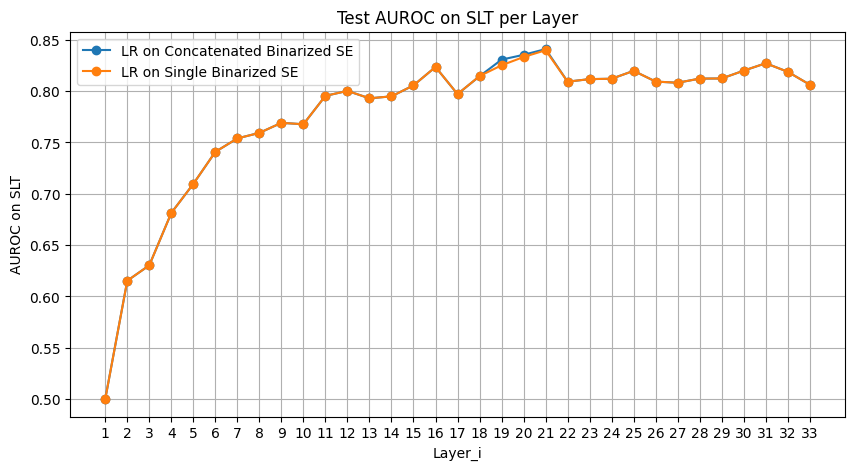

SLT: max AUROC for LR trained and tested on Concatenated Binarized SE: 0.8410 at 37 layer
SLT: max AUROC for LR trained and tested on Binary SE: 0.8399 at 21 layer


In [88]:
# Plot single-input model auroc together with concatenated-input model auroc
# ccsblr_test_aucs_arr = list(ccsblr_test_aucs.values())
ccsblr_test_aucs_arr = list(sblr_test_aucs[:min_layer]) + list(ccsblr_test_aucs.values()) + list(sblr_test_aucs[max_layer:])

# plot_1d_metrics([ccsblr_test_aucs_arr, sblr_test_aucs[min_layer:all_max_layer-1]], ['LR on Concatenated Binarized SE', 'LR on Single Binarized SE'], 'AUROC on SLT', preset_layer_indices=range(min_layer+1, all_max_layer))
plot_1d_metrics([ccsblr_test_aucs_arr, sblr_test_aucs], ['LR on Concatenated Binarized SE', 'LR on Single Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained and tested on Concatenated Binarized SE: {max(ccsblr_test_aucs_arr):.4f} at {min_layer+np.argmax(ccsblr_test_aucs_arr)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

In [140]:
# Select best top-k layers 
sblr_best_auc_indices = np.argsort(sblr_test_aucs)[::-1]

topksblr_test_accs = {}
topksblr_test_aucs = {}
topksblr_models = {}

for top_k in range(1, 10):
    indices = sblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksblr_test_accs[tuple(indices)] = test_acc
    topksblr_test_aucs[tuple(indices)] = test_auc
    topksblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [21]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7444, AUROC: 0.8096
Training Loss: 0.0149, Validation Loss: 1.2251
Test Loss: 1.0507, Test Accuracy: 0.7620, AUROC: 0.8399
Training on top-2 Datasets indexed [21, 20]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7478, AUROC: 0.8135
Training Loss: 0.0080, Validation Loss: 1.2898
Test Loss: 1.1526, Test Accuracy: 0.7660, AUROC: 0.8392
Training on top-3 Datasets indexed [21, 20, 31]


...

Validation Accuracy: 0.7578, AUROC: 0.8191
Training Loss: 0.0006, Validation Loss: 1.8077
Test Loss: 1.5900, Test Accuracy: 0.7660, AUROC: 0.8430
Training on top-8 Datasets indexed [21, 20, 31, 19, 16, 30, 25, 32]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7611, AUROC: 0.8228
Training Loss: 0.0006, Validation Loss: 1.8376
Test Loss: 1.6975, Test Accuracy: 0.7720, AUROC: 0.8395
Training on top-9 Datasets indexed [21, 20, 31, 19, 16, 30, 25, 32, 18]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7689, AUROC: 0.8234
Training Loss: 0.0006, Validation Loss: 1.8189
Test Loss: 1.6654, Test Accuracy: 0.7680, AUROC: 0.8410


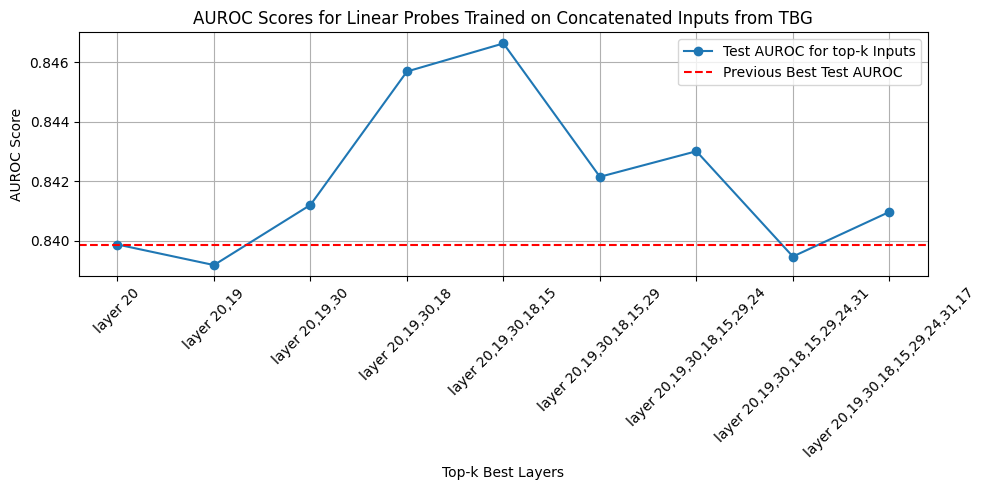

In [158]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(sblr_test_aucs), topksblr_test_aucs, 'TBG')

#### Compare TBG and SLT at predicting b-SE

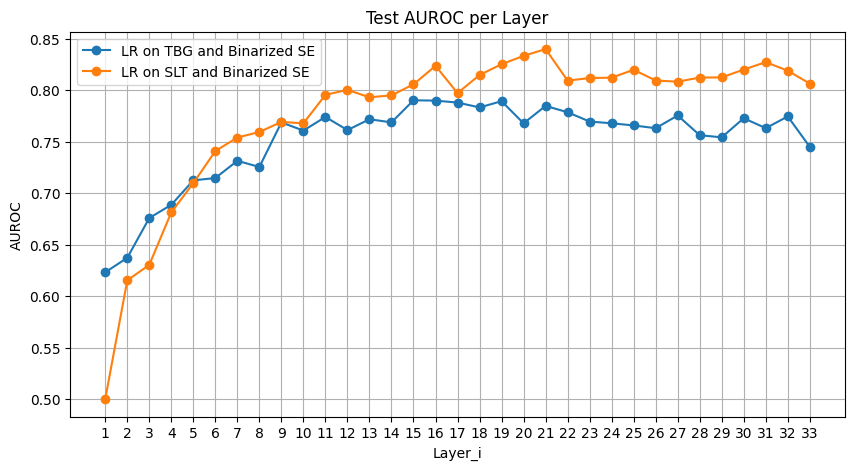

TBG: max AUROC for LR trained and tested on Binarized SE: 0.7901 at 15 layer
SLT: max AUROC for LR trained and tested on Binarized SE: 0.8399 at 21 layer


In [93]:
plot_1d_metrics([tblr_test_aucs, sblr_test_aucs], ['LR on TBG and Binarized SE', 'LR on SLT and Binarized SE'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Binarized SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Binarized SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [23]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([5000]) tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 1.])


In [24]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [25]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.7720


In [26]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.7600, AUROC: 0.5843
Training Loss: 0.4868, Validation Loss: 0.5420
Test Loss: 0.5148, Test Accuracy: 0.7740, AUROC: 0.6567
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.7589, AUROC: 0.5963
Training Loss: 0.4577, Validation Loss: 0.5425
Test Loss: 0.5054, Test Accuracy: 0.7700, AUROC: 0.6683
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.7400, AUROC: 0.5924
Training Loss: 0.4069, Validation Loss: 0.5552
Test Loss: 0.5010, Test Accuracy: 0.7520, AUROC: 0.6926
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.7356, AUROC: 0.5951
Training Loss: 0.3559, Validation Loss: 0.5789
Test Loss: 0.5102, Test Accuracy: 0.7480, AUROC: 0.6784
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.7278, AUROC: 0.6123
Training Loss: 0.3181, Validation Loss: 0.6020
Test Loss: 0.5136, Test Accuracy: 0.7600, AUROC: 0.6831
Training on TBG-Acc Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7467, AUROC: 0.6179
Training Loss: 0.2760, Validation Loss: 0.6251
Test Loss: 0.5501, Test Accuracy: 0.7520, AUROC: 0.6827
Training on TBG-Acc Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7211, AUROC: 0.6258
Training Loss: 0.2272, Validation Loss: 0.6622
Test Loss: 0.5763, Test Accuracy: 0.7480, AUROC: 0.6978
Training on TBG-Acc Dataset 8/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7433, AUROC: 0.7002
Training Loss: 0.0024, Validation Loss: 1.8499
Test Loss: 1.6249, Test Accuracy: 0.7500, AUROC: 0.7245
Training on TBG-Acc Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7344, AUROC: 0.6997
Training Loss: 0.0021, Validation Loss: 1.8573
Test Loss: 1.6833, Test Accuracy: 0.7480, AUROC: 0.7211
Training on TBG-Acc Dataset 33/33
Validation Accuracy: 0.7156, AUROC: 0.6608
Training Loss: 0.0039, Validation Loss: 2.3134
Test Loss: 1.8549, Test Accuracy: 0.7420, AUROC: 0.7095


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


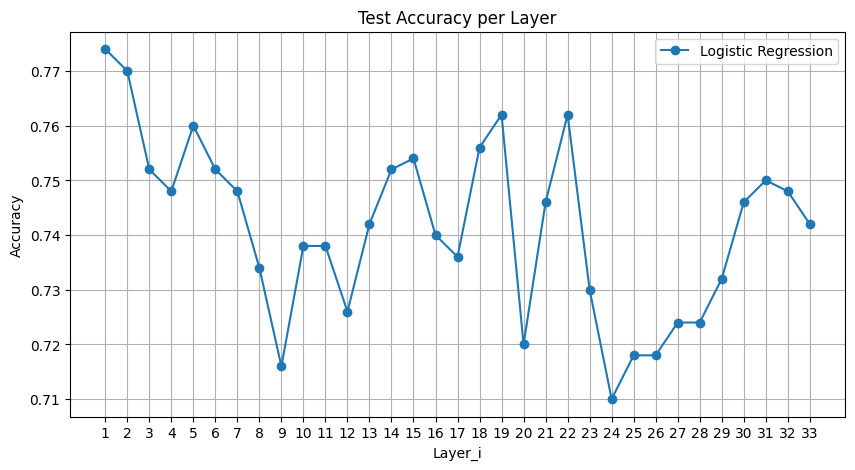

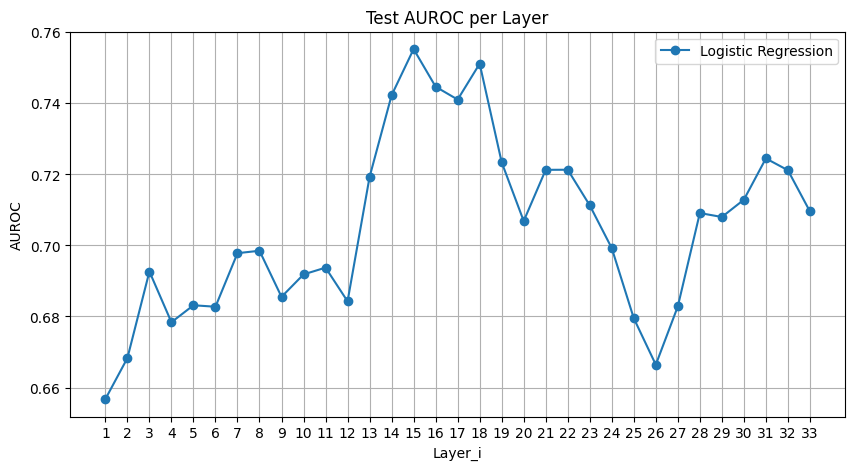

In [27]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [28]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.7552 at layer 15


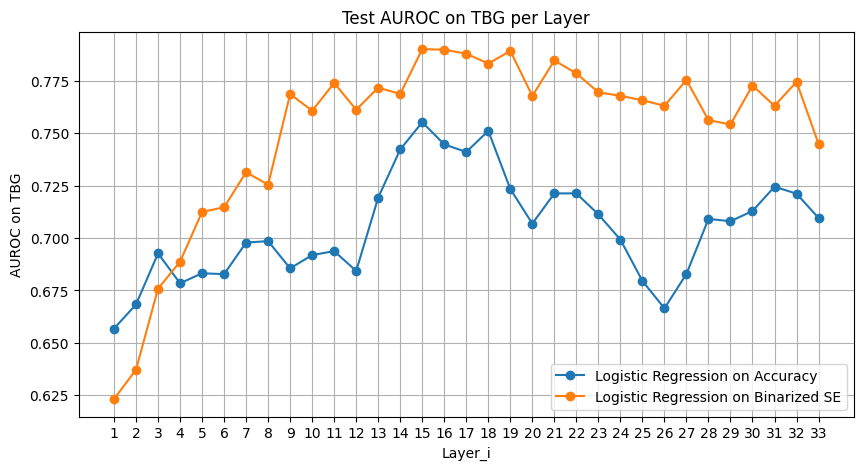

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7552 at 15 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.7901 at 15 layer


In [43]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [29]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [30]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.7633, AUROC: 0.5000
Training Loss: 0.5472, Validation Loss: 0.5472
Test Loss: 0.5371, Test Accuracy: 0.7720, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.7633, AUROC: 0.5718
Training Loss: 0.5402, Validation Loss: 0.5432
Test Loss: 0.5300, Test Accuracy: 0.7720, AUROC: 0.6098
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.7633, AUROC: 0.5706
Training Loss: 0.5368, Validation Loss: 0.5420
Test Loss: 0.5249, Test Accuracy: 0.7720, AUROC: 0.6258
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.7633, AUROC: 0.6010
Training Loss: 0.5246, Validation Loss: 0.5357
Test Loss: 0.5172, Test Accuracy: 0.7720, AUROC: 0.6483
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.7633, AUROC: 0.6272
Training Loss: 0.5146, Validation Loss: 0.5298
Test Loss: 0.5105, Test Accuracy: 0.7720, AUROC: 0.6635
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.7633, AUROC: 0.6680
Training Loss: 0.4859, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7622, AUROC: 0.6858
Training Loss: 0.4142, Validation Loss: 0.5153
Test Loss: 0.4794, Test Accuracy: 0.7760, AUROC: 0.7301
Training on SLT-Acc Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7678, AUROC: 0.6995
Training Loss: 0.3878, Validation Loss: 0.5080
Test Loss: 0.4840, Test Accuracy: 0.7840, AUROC: 0.7205
Training on SLT-Acc Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7200, AUROC: 0.6680
Training Loss: 0.0027, Validation Loss: 2.0878
Test Loss: 1.8302, Test Accuracy: 0.7580, AUROC: 0.7205
Training on SLT-Acc Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7178, AUROC: 0.6623
Training Loss: 0.0024, Validation Loss: 2.2017
Test Loss: 1.8999, Test Accuracy: 0.7600, AUROC: 0.7247
Training on SLT-Acc Dataset 33/33
Validation Accuracy: 0.7400, AUROC: 0.6593
Training Loss: 0.0069, Validation Loss: 2.3974
Test Loss: 2.2178, Test Accuracy: 0.7360, AUROC: 0.6972


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


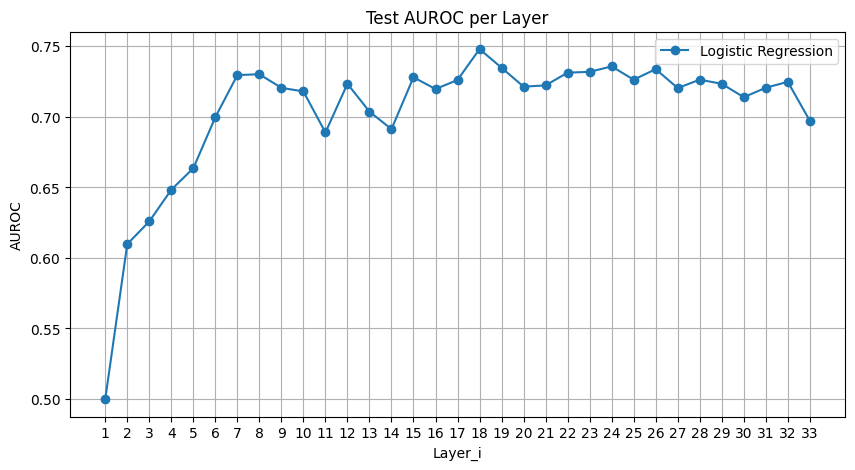

In [31]:
# plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [32]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.7479 at layer 18


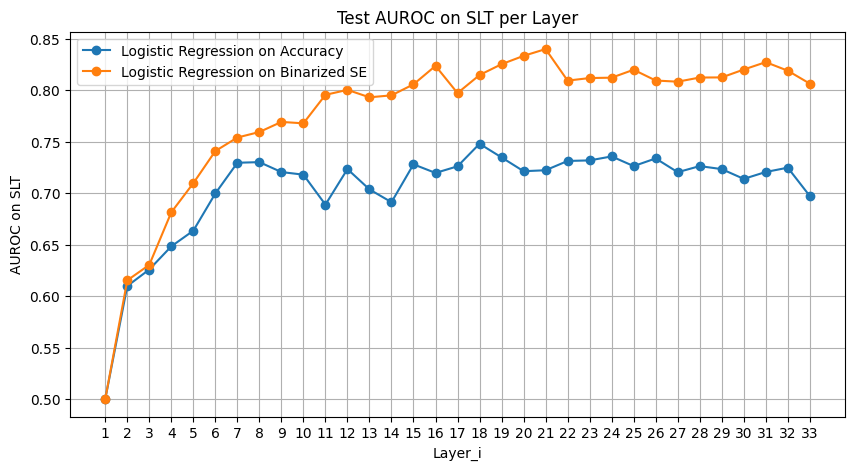

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7479 at 18 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8399 at 21 layer


In [44]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

#### Compare TBG and SLT at predicting Acc

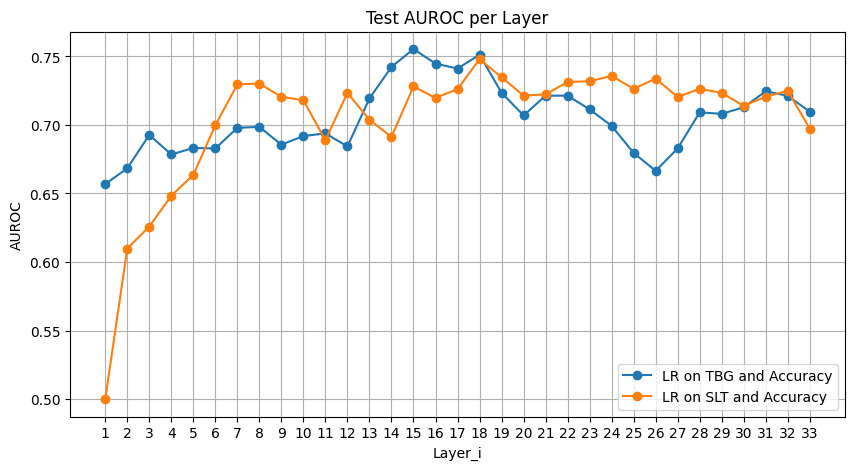

TBG: max AUROC for LR trained and tested on Accuracy: 0.7552 at 15 layer
SLT: max AUROC for LR trained and tested on Accuracy: 0.7479 at 18 layer


In [94]:
plot_1d_metrics([talr_test_aucs, salr_test_aucs], ['LR on TBG and Accuracy', 'LR on SLT and Accuracy'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [153]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [34]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.6578, AUROC: 0.6692
Training Loss: 0.5656, Validation Loss: 0.6266
Test Loss: 0.5932, Test Accuracy: 0.6620, AUROC: 0.6310
Training on TBG Dataset 2/33
Validation Accuracy: 0.6467, AUROC: 0.6899
Training Loss: 0.5255, Validation Loss: 0.6149
Test Loss: 0.5953, Test Accuracy: 0.6400, AUROC: 0.6475
Training on TBG Dataset 3/33
Validation Accuracy: 0.6633, AUROC: 0.7117
Training Loss: 0.4595, Validation Loss: 0.6121
Test Loss: 0.5929, Test Accuracy: 0.6720, AUROC: 0.6906
Training on TBG Dataset 4/33
Validation Accuracy: 0.6600, AUROC: 0.7048
Training Loss: 0.3971, Validation Loss: 0.6372
Test Loss: 0.6192, Test Accuracy: 0.6400, AUROC: 0.6752
Training on TBG Dataset 5/33
Validation Accuracy: 0.6489, AUROC: 0.6868
Training Loss: 0.3517, Validation Loss: 0.6873
Test Loss: 0.6498, Test Accuracy: 0.6520, AUROC: 0.6813
Training on TBG Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6589, AUROC: 0.6972
Training Loss: 0.3041, Validation Loss: 0.7174
Test Loss: 0.6949, Test Accuracy: 0.6600, AUROC: 0.6853
Training on TBG Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6667, AUROC: 0.7087
Training Loss: 0.2528, Validation Loss: 0.7504
Test Loss: 0.7293, Test Accuracy: 0.6640, AUROC: 0.7058
Training on TBG Dataset 8/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7333, AUROC: 0.7848
Training Loss: 0.0024, Validation Loss: 1.7744
Test Loss: 2.4659, Test Accuracy: 0.6680, AUROC: 0.7403
Training on TBG Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7156, AUROC: 0.7790
Training Loss: 0.0021, Validation Loss: 1.9608
Test Loss: 2.6676, Test Accuracy: 0.6740, AUROC: 0.7332
Training on TBG Dataset 33/33
Validation Accuracy: 0.6989, AUROC: 0.7523
Training Loss: 0.0040, Validation Loss: 2.2960
Test Loss: 2.7636, Test Accuracy: 0.6680, AUROC: 0.7251


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


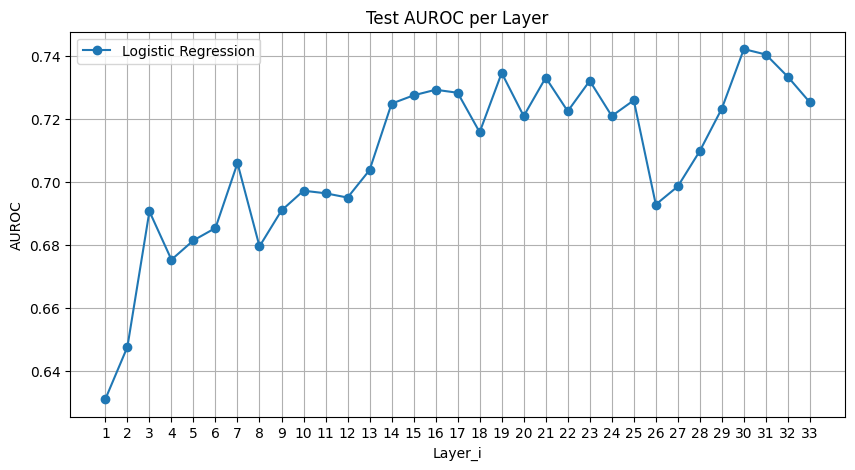

In [35]:
# plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

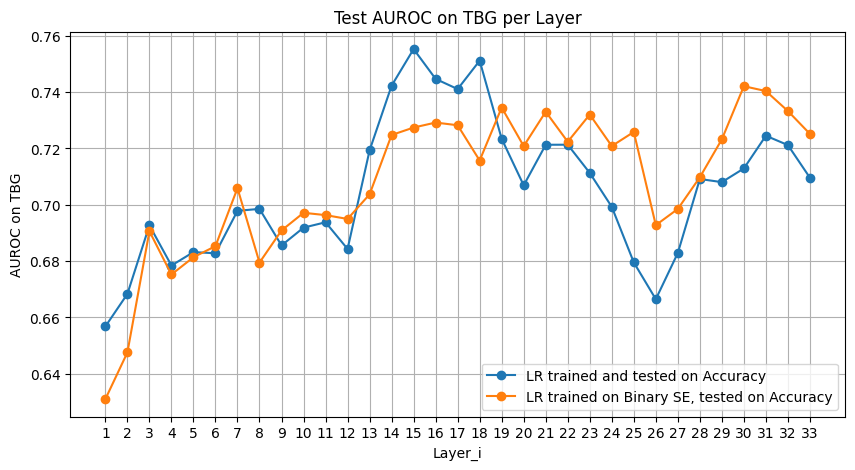

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7552 at 15 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7420 at 30 layer


In [36]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

In [155]:
## Use trained probes on concat-ed inputs of best layers
topktablr_test_accs = {}
topktablr_test_aucs = {}

for indices in topktblr_models.keys():
    print(f"Testing on top-{len(indices)} TBG Datasets trained probe:", list(indices))
    _, _, X_test, _, _, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = topktblr_models[indices]
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktablr_test_accs[tuple(indices)] = test_acc
    topktablr_test_aucs[tuple(indices)] = test_auc

Testing on top-1 TBG Datasets trained probe: [14]
Test Loss: 1.3328, Test Accuracy: 0.6600, AUROC: 0.7274
Testing on top-2 TBG Datasets trained probe: [14, 15]
Test Loss: 1.4411, Test Accuracy: 0.6920, AUROC: 0.7371
Testing on top-3 TBG Datasets trained probe: [14, 15, 18]
Test Loss: 1.5214, Test Accuracy: 0.6840, AUROC: 0.7455
Testing on top-4 TBG Datasets trained probe: [14, 15, 18, 16]
Test Loss: 1.5706, Test Accuracy: 0.6720, AUROC: 0.7436
Testing on top-5 TBG Datasets trained probe: [14, 15, 18, 16, 20]
Test Loss: 1.6996, Test Accuracy: 0.6820, AUROC: 0.7494
Testing on top-6 TBG Datasets trained probe: [14, 15, 18, 16, 20, 17]
Test Loss: 1.7450, Test Accuracy: 0.6880, AUROC: 0.7495
Testing on top-7 TBG Datasets trained probe: [14, 15, 18, 16, 20, 17, 21]
Test Loss: 1.9429, Test Accuracy: 0.6800, AUROC: 0.7466
Testing on top-8 TBG Datasets trained probe: [14, 15, 18, 16, 20, 17, 21, 26]
Test Loss: 2.1963, Test Accuracy: 0.6860, AUROC: 0.7480
Testing on top-9 TBG Datasets trained pr

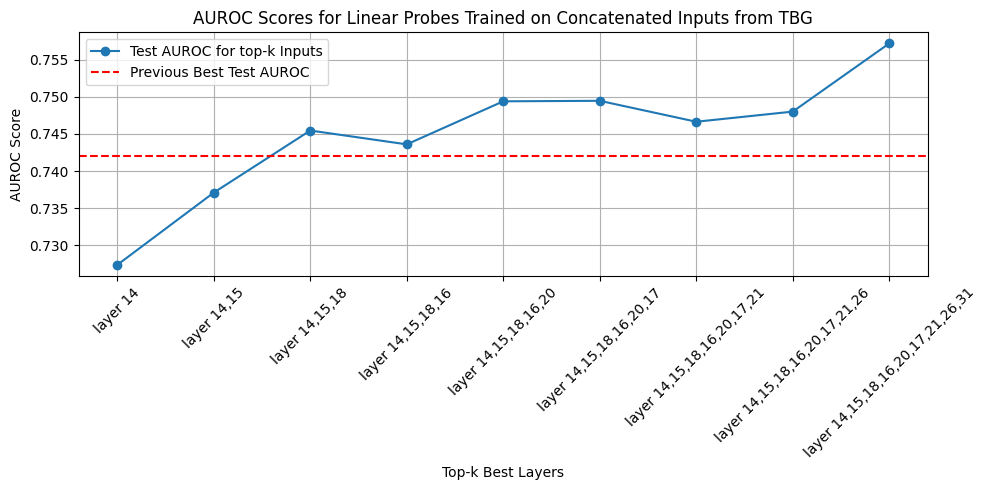

In [159]:
plot_metrics_w_constant(max(tablr_test_aucs), topktablr_test_aucs, 'TBG')

Now we test on SLT embeddings.

In [151]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [38]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.6222, AUROC: 0.5000
Training Loss: 0.6707, Validation Loss: 0.6636
Test Loss: 0.5994, Test Accuracy: 0.7720, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.6222, AUROC: 0.5910
Training Loss: 0.6628, Validation Loss: 0.6578
Test Loss: 0.5947, Test Accuracy: 0.7720, AUROC: 0.5981
Training on SLT Dataset 3/33
Validation Accuracy: 0.6222, AUROC: 0.6081
Training Loss: 0.6583, Validation Loss: 0.6541
Test Loss: 0.5904, Test Accuracy: 0.7720, AUROC: 0.6101
Training on SLT Dataset 4/33
Validation Accuracy: 0.6411, AUROC: 0.6458
Training Loss: 0.6386, Validation Loss: 0.6392
Test Loss: 0.5821, Test Accuracy: 0.7540, AUROC: 0.6365
Training on SLT Dataset 5/33
Validation Accuracy: 0.6433, AUROC: 0.6623
Training Loss: 0.6191, Validation Loss: 0.6276
Test Loss: 0.5759, Test Accuracy: 0.7460, AUROC: 0.6567
Training on SLT Dataset 6/33
Validation Accuracy: 0.6656, AUROC: 0.6972
Training Loss: 0.5746, Validation Loss: 0.6051
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6811, AUROC: 0.7126
Training Loss: 0.5366, Validation Loss: 0.5976
Test Loss: 0.5543, Test Accuracy: 0.7060, AUROC: 0.7212
Training on SLT Dataset 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6978, AUROC: 0.7385
Training Loss: 0.4770, Validation Loss: 0.5826
Test Loss: 0.5803, Test Accuracy: 0.6880, AUROC: 0.7055
Training on SLT Dataset 9/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7633, AUROC: 0.8108
Training Loss: 0.0021, Validation Loss: 1.8319
Test Loss: 2.7245, Test Accuracy: 0.6940, AUROC: 0.7524
Training on SLT Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7578, AUROC: 0.8196
Training Loss: 0.0020, Validation Loss: 1.7803
Test Loss: 2.7241, Test Accuracy: 0.7040, AUROC: 0.7589
Training on SLT Dataset 33/33
Validation Accuracy: 0.7411, AUROC: 0.7992
Training Loss: 0.0046, Validation Loss: 1.9561
Test Loss: 2.7730, Test Accuracy: 0.7040, AUROC: 0.7594


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


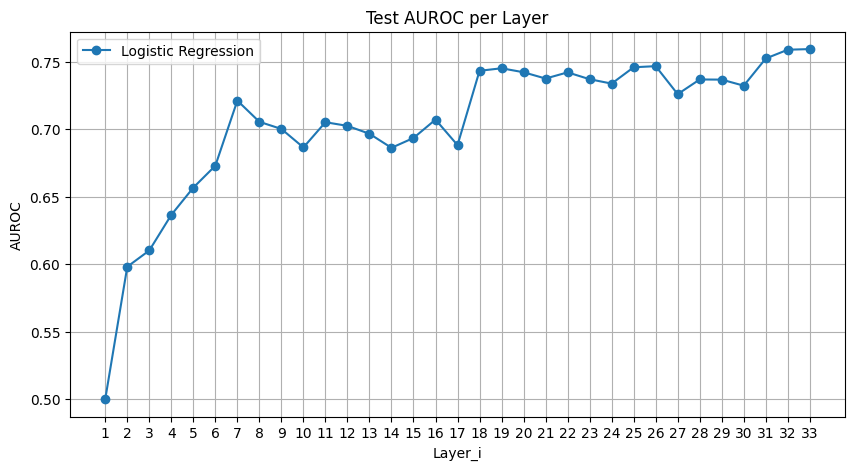

In [41]:
# plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

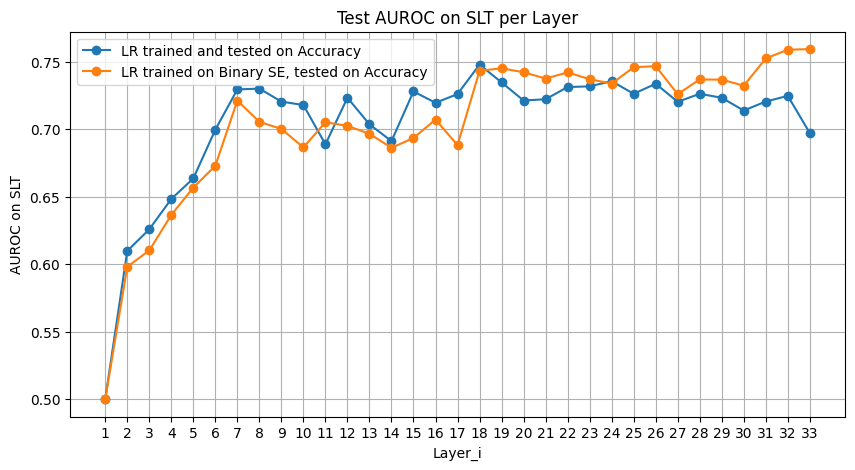

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7479 at 18 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7594 at 33 layer


In [42]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")

In [152]:
## Use trained probes on concat-ed inputs of best layers
topksablr_test_accs = {}
topksablr_test_aucs = {}

for indices in topksblr_models.keys():
    print(f"Testing on top-{len(indices)} SLT Datasets trained probe:", list(indices))
    _, _, X_test, _, _, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = topksblr_models[indices]
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksablr_test_accs[tuple(indices)] = test_acc
    topksablr_test_aucs[tuple(indices)] = test_auc

# topksablr_test_aucs

Testing on top-1 SLT Datasets trained probe: [20]
Test Loss: 1.7698, Test Accuracy: 0.6760, AUROC: 0.7375
Testing on top-2 SLT Datasets trained probe: [20, 19]
Test Loss: 1.9041, Test Accuracy: 0.6680, AUROC: 0.7443
Testing on top-3 SLT Datasets trained probe: [20, 19, 30]
Test Loss: 2.3409, Test Accuracy: 0.7040, AUROC: 0.7621
Testing on top-4 SLT Datasets trained probe: [20, 19, 30, 18]
Test Loss: 2.2603, Test Accuracy: 0.7060, AUROC: 0.7652
Testing on top-5 SLT Datasets trained probe: [20, 19, 30, 18, 15]
Test Loss: 2.2867, Test Accuracy: 0.7120, AUROC: 0.7650
Testing on top-6 SLT Datasets trained probe: [20, 19, 30, 18, 15, 29]
Test Loss: 2.5968, Test Accuracy: 0.7040, AUROC: 0.7556
Testing on top-7 SLT Datasets trained probe: [20, 19, 30, 18, 15, 29, 24]
Test Loss: 2.6961, Test Accuracy: 0.7000, AUROC: 0.7565
Testing on top-8 SLT Datasets trained probe: [20, 19, 30, 18, 15, 29, 24, 31]
Test Loss: 2.7913, Test Accuracy: 0.7140, AUROC: 0.7591
Testing on top-9 SLT Datasets trained pr

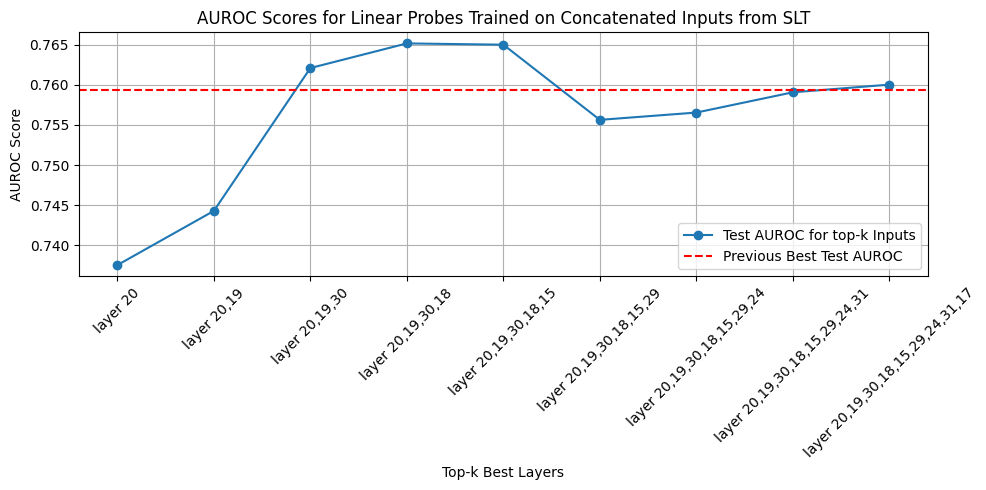

In [160]:
plot_metrics_w_constant(max(sablr_test_aucs), topksablr_test_aucs, 'SLT')

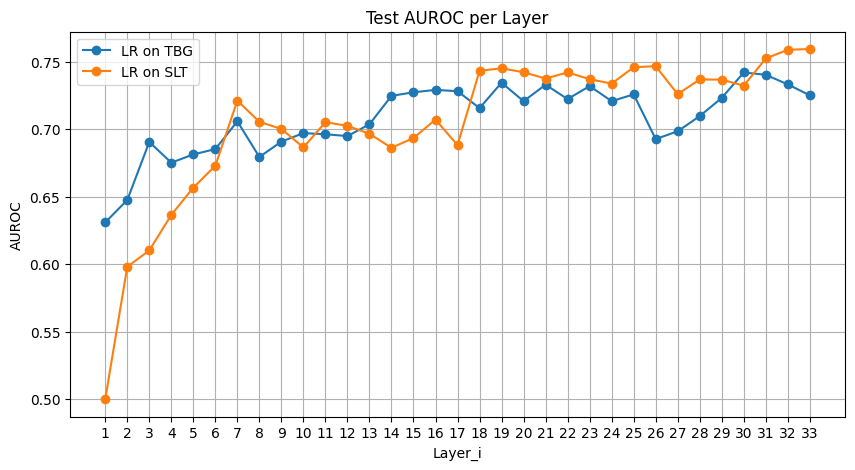

TBG: max AUROC for LR trained on b-SE and tested on Accuracy: 0.7420 at 30 layer
SLT: max AUROC for LR trained on b-SE and tested on Accuracy: 0.7594 at 33 layer


In [95]:
# Compare TBG and SLT at predicting Acc from probes trained on b-SE
plot_1d_metrics([tablr_test_aucs, sablr_test_aucs], ['LR on TBG', 'LR on SLT'], 'AUROC')
print(f"TBG: max AUROC for LR trained on b-SE and tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on b-SE and tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")